# **Applied Machine Learning Lab-(MCSE630P)**

**Assignment 8-SVM**

**Name:** Shrihariharan S [24MCS1058]

Experiment on SVM, We used data of different peoples data and their details like
Age,
Gender,
Income,
Education,
Marital Status,
Number of Children,
Home Ownership,
to calculate the credit score of each person

We also used Grid search for Hyperparameter tuning for tuning the model and used confusion matrix for visualising the results.

Kaggle dataset:https://www.kaggle.com/datasets/sujithmandala/credit-score-classification-dataset

In [57]:
! pip install -q kaggle

In [58]:
!mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [59]:
! chmod 600 ~/.kaggle/kaggle.json

In [60]:
! kaggle datasets list

ref                                                          title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
valakhorasani/mobile-device-usage-and-user-behavior-dataset  Mobile Device Usage and User Behavior Dataset        11KB  2024-09-28 20:21:12          13615        287  1.0              
valakhorasani/gym-members-exercise-dataset                   Gym Members Exercise Dataset                         22KB  2024-10-06 11:27:38           7119        114  1.0              
yusufdelikkaya/datascience-salaries-2024                     Data Science Salaries 2024                           69KB  2024-10-23 18:39:50            994         28  0.88235295       
lainguyn123/student-performance-factors                      Student Perfor

In [61]:
! kaggle datasets download -d sujithmandala/credit-score-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/sujithmandala/credit-score-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
credit-score-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [62]:
! unzip '/content/credit-score-classification-dataset.zip'

Archive:  /content/credit-score-classification-dataset.zip
replace Credit Score Classification Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df=pd.read_csv("/content/Credit Score Classification Dataset.csv")

In [65]:
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High


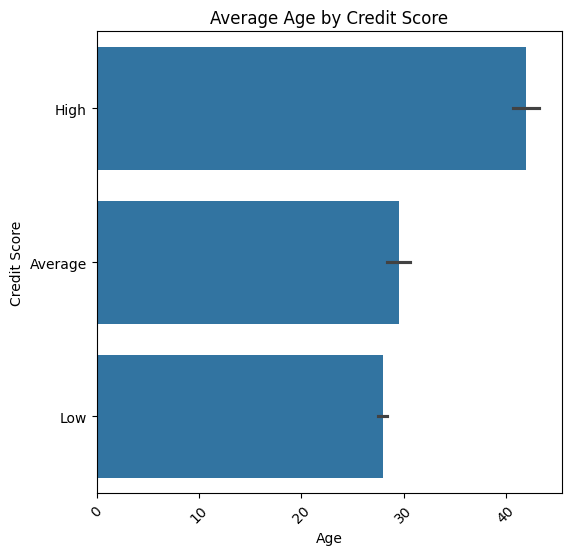

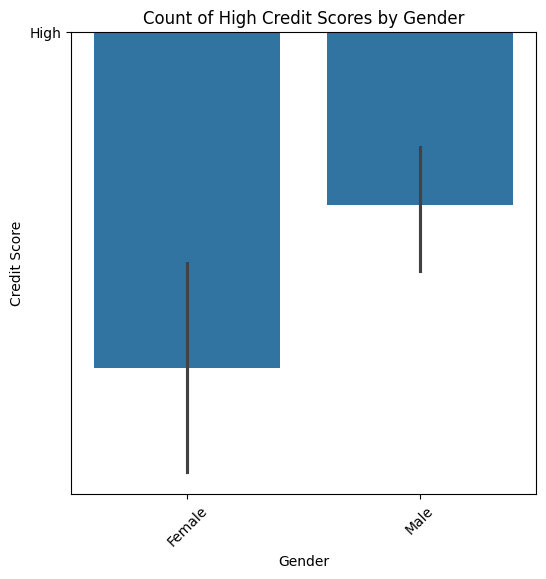

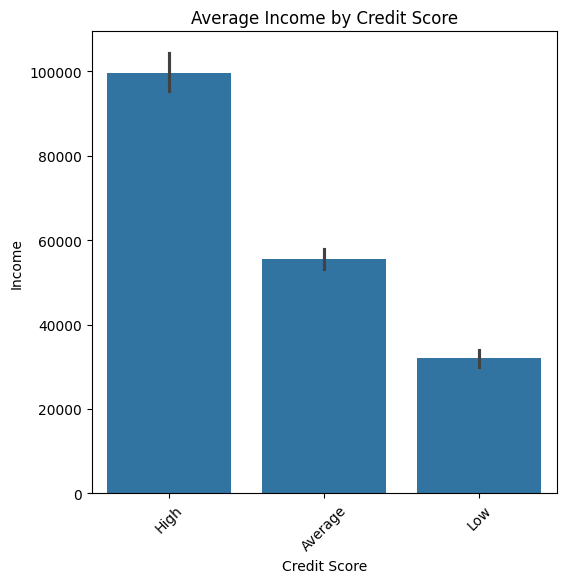

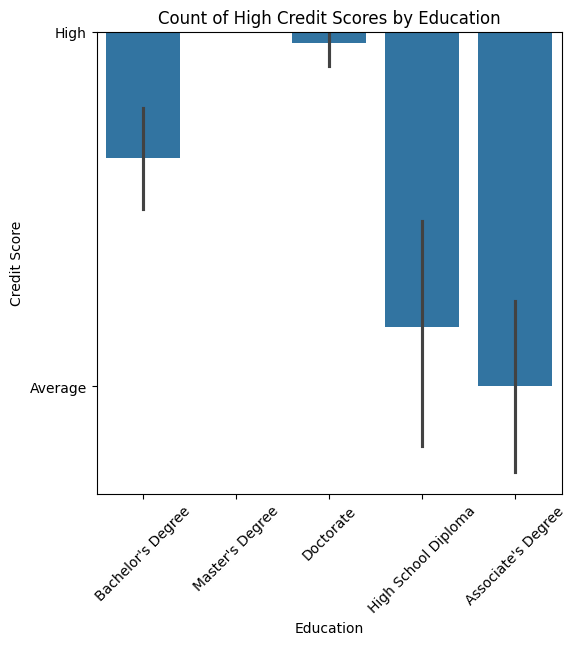

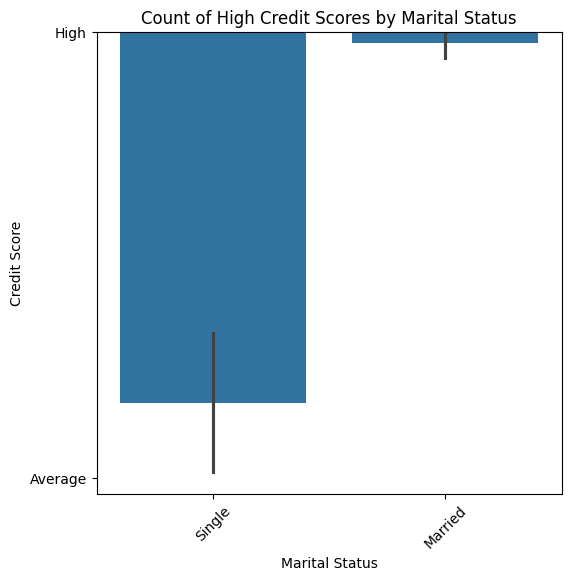

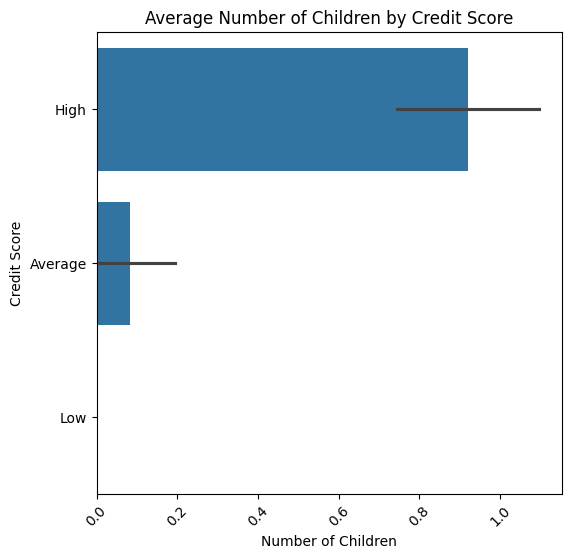

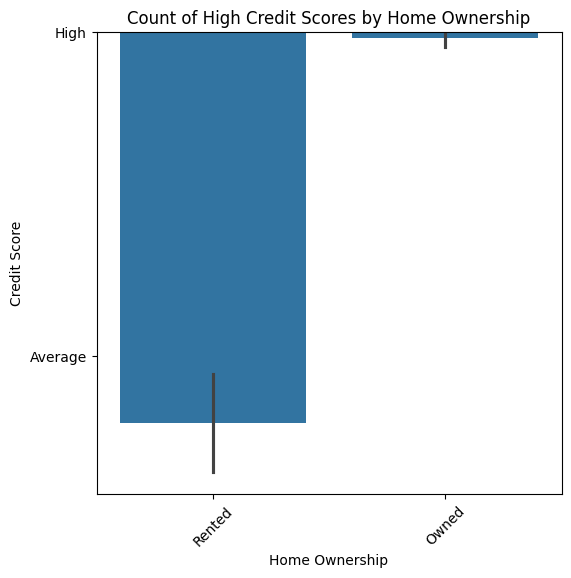

In [127]:
def plot_bar_chart(x, y, title):
    plt.figure(figsize=(6, 6))
    sns.barplot(x=x, y=y, data=df, estimator='mean' if isinstance(y, str) else None)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=45)
    plt.show()

# Plot each chart
plot_bar_chart('Age', 'Credit Score', 'Average Age by Credit Score')
plot_bar_chart('Gender', 'Credit Score', 'Count of High Credit Scores by Gender')
plot_bar_chart( 'Credit Score', 'Income','Average Income by Credit Score')
plot_bar_chart('Education', 'Credit Score', 'Count of High Credit Scores by Education')
plot_bar_chart('Marital Status', 'Credit Score', 'Count of High Credit Scores by Marital Status')
plot_bar_chart('Number of Children', 'Credit Score', 'Average Number of Children by Credit Score')
plot_bar_chart('Home Ownership', 'Credit Score', 'Count of High Credit Scores by Home Ownership')

In [66]:
df.isnull().sum() #checking for null values

,0
Age,0
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [67]:
df['Credit Score'].value_counts() # checking the distribution of credit score

,count
Credit Score,
High,113
Average,36
Low,15


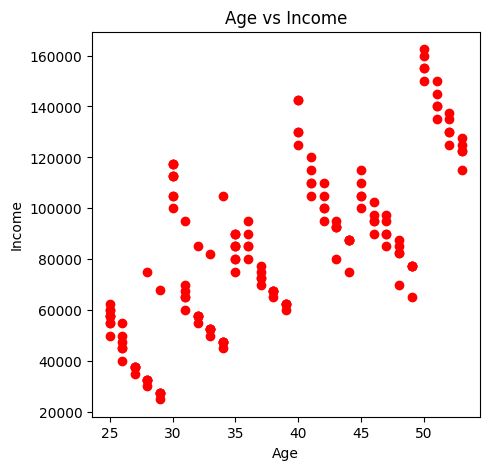

In [68]:
plt.figure(figsize=(5, 5))
plt.scatter(df['Age'], df['Income'], color='red', marker='o')
plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show() # visualising age vs income in scatter plot

<Axes: ylabel='Gender'>

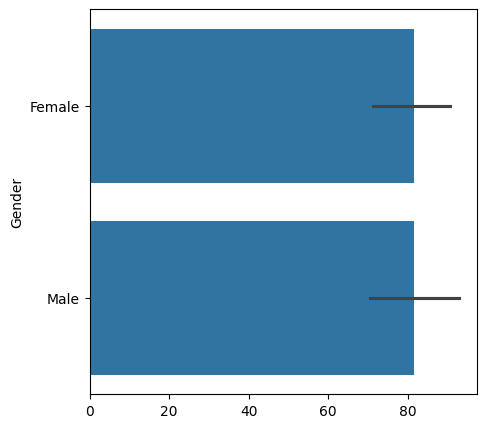

In [119]:
plt.figure(figsize=(5, 5))
sns.barplot(df['Gender']) # visualising Gender Distribution

In [70]:
df.Gender.value_counts()

,count
Gender,
Female,86
Male,78


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital Status      164 non-null    object
 5   Number of Children  164 non-null    int64 
 6   Home Ownership      164 non-null    object
 7   Credit Score        164 non-null    object
dtypes: int64(3), object(5)
memory usage: 10.4+ KB


In [117]:
df.describe() # distrubution of dataset

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439
std,8.477289,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,30.750000,57500.000000,0.000000
50%,37.000000,83750.000000,0.000000
75%,45.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


In [72]:
X=df.drop('Credit Score', axis=1) # splitting the x and y values
y=df['Credit Score']

In [73]:
X

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership
0,25,Female,50000,Bachelor's Degree,Single,0,Rented
1,30,Male,100000,Master's Degree,Married,2,Owned
2,35,Female,75000,Doctorate,Married,1,Owned
3,40,Male,125000,High School Diploma,Single,0,Owned
4,45,Female,100000,Bachelor's Degree,Married,3,Owned
...,...,...,...,...,...,...,...
159,29,Female,27500,High School Diploma,Single,0,Rented
160,34,Male,47500,Associate's Degree,Single,0,Rented
161,39,Female,62500,Bachelor's Degree,Married,2,Owned
162,44,Male,87500,Master's Degree,Single,0,Owned


In [74]:
X=pd.get_dummies(X, columns=['Gender','Education','Marital Status','Home Ownership']) # nomial encoding using one hot encoding (by get_dummies function)

In [75]:
X

,Age,Income,Number of Children,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,50000,0,True,False,False,True,False,False,False,False,True,False,True
1,30,100000,2,False,True,False,False,False,False,True,True,False,True,False
2,35,75000,1,True,False,False,False,True,False,False,True,False,True,False
3,40,125000,0,False,True,False,False,False,True,False,False,True,True,False
4,45,100000,3,True,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,29,27500,0,True,False,False,False,False,True,False,False,True,False,True
160,34,47500,0,False,True,True,False,False,False,False,False,True,False,True
161,39,62500,2,True,False,False,True,False,False,False,True,False,True,False
162,44,87500,0,False,True,False,False,False,False,True,False,True,True,False


In [77]:
X= X.replace({True: 1, False: 0}) # replacing true with 1 and false with 0

<ipython-input-77-a9cf616ef465>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X= X.replace({True: 1, False: 0})


In [121]:
X

,Age,Income,Number of Children,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,-1.535320,-1.043483,-0.740862,1,0,0,1,0,0,0,0,1,0,1
1,-0.943702,0.501720,1.530191,0,1,0,0,0,0,1,1,0,1,0
2,-0.352085,-0.270882,0.394665,1,0,0,0,1,0,0,1,0,1,0
3,0.239533,1.274322,-0.740862,0,1,0,0,0,1,0,0,1,1,0
4,0.831151,0.501720,2.665717,1,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,-1.062026,-1.738825,-0.740862,1,0,0,0,0,1,0,0,1,0,1
160,-0.470408,-1.120744,-0.740862,0,1,1,0,0,0,0,0,1,0,1
161,0.121209,-0.657183,1.530191,1,0,0,1,0,0,0,1,0,1,0
162,0.712827,0.115419,-0.740862,0,1,0,0,0,0,1,0,1,1,0


<Axes: >

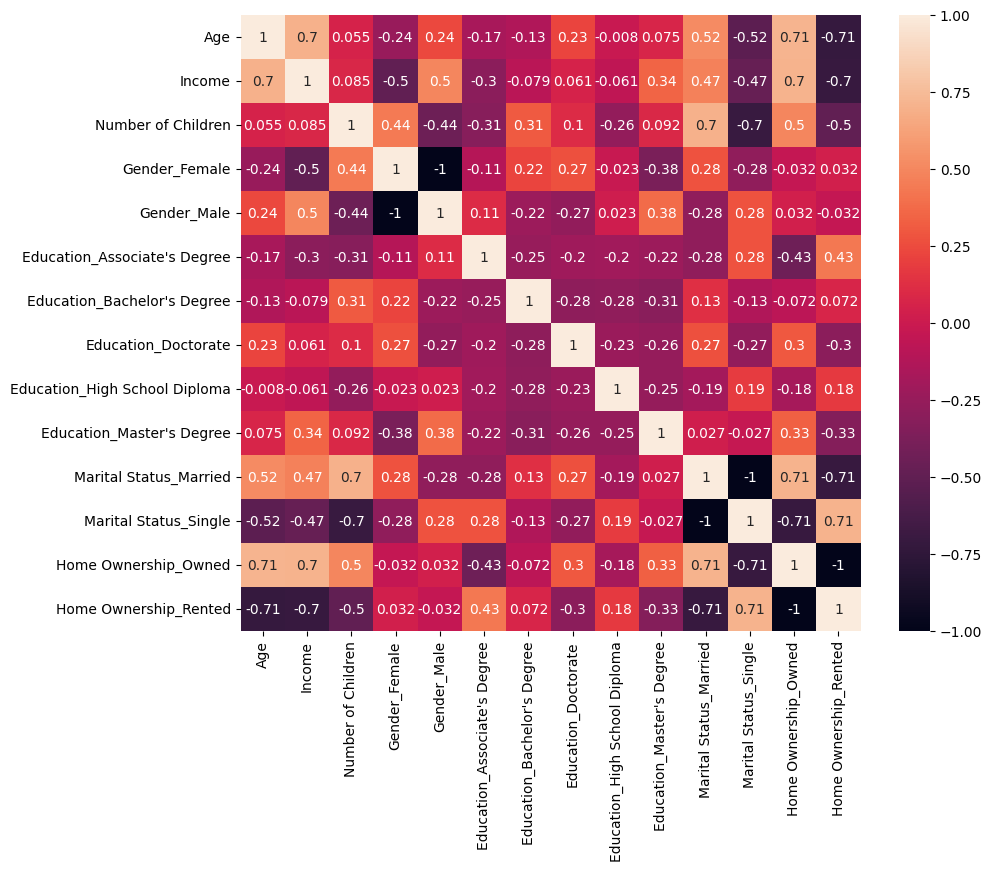

In [124]:
plt.figure(figsize=(10, 8))
corr=X.corr() # correlation matrix
sns.heatmap(corr, annot=True)

In [79]:
y

,Credit Score
0,High
1,High
2,High
3,High
4,High
...,...
159,Low
160,Average
161,High
162,High


In [80]:
y.value_counts()

,count
Credit Score,
High,113
Average,36
Low,15


In [81]:
y=y.map({
    "High": 2,
    "Average": 1,
    "Low": 0
}) # label encoding using dictionary

In [82]:
y

,Credit Score
0,2
1,2
2,2
3,2
4,2
...,...
159,0
160,1
161,2
162,2


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [84]:
X=pd.DataFrame(X)
X

,Age,Income,Number of Children,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,50000,0,1,0,0,1,0,0,0,0,1,0,1
1,30,100000,2,0,1,0,0,0,0,1,1,0,1,0
2,35,75000,1,1,0,0,0,1,0,0,1,0,1,0
3,40,125000,0,0,1,0,0,0,1,0,0,1,1,0
4,45,100000,3,1,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,29,27500,0,1,0,0,0,0,1,0,0,1,0,1
160,34,47500,0,0,1,1,0,0,0,0,0,1,0,1
161,39,62500,2,1,0,0,1,0,0,0,1,0,1,0
162,44,87500,0,0,1,0,0,0,0,1,0,1,1,0


In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [86]:
columns_to_scale = ["Age", "Income", "Number of Children"] # normalising/standard scaling the continuous data
scaler = StandardScaler()
X[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [87]:
X

,Age,Income,Number of Children,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,-1.535320,-1.043483,-0.740862,1,0,0,1,0,0,0,0,1,0,1
1,-0.943702,0.501720,1.530191,0,1,0,0,0,0,1,1,0,1,0
2,-0.352085,-0.270882,0.394665,1,0,0,0,1,0,0,1,0,1,0
3,0.239533,1.274322,-0.740862,0,1,0,0,0,1,0,0,1,1,0
4,0.831151,0.501720,2.665717,1,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,-1.062026,-1.738825,-0.740862,1,0,0,0,0,1,0,0,1,0,1
160,-0.470408,-1.120744,-0.740862,0,1,1,0,0,0,0,0,1,0,1
161,0.121209,-0.657183,1.530191,1,0,0,1,0,0,0,1,0,1,0
162,0.712827,0.115419,-0.740862,0,1,0,0,0,0,1,0,1,1,0


In [88]:
svm_model=SVC(random_state=2) #model building

In [89]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2) # Train test split

In [90]:
svm_model.fit(X_train, y_train) #fitting the model

SVC(random_state=2)

In [92]:
y_pred = svm_model.predict(X_test) # predicting the outcome

In [118]:
accuracy = accuracy_score(y_test, y_pred)
y_pred

array([1, 2, 2, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 1, 2, 1, 1,
       2, 2, 0, 1, 2, 2, 1, 2, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2])

In [96]:
accuracy

0.8780487804878049

In [100]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 4,  0,  0],
       [ 4, 11,  0],
       [ 0,  1, 21]])

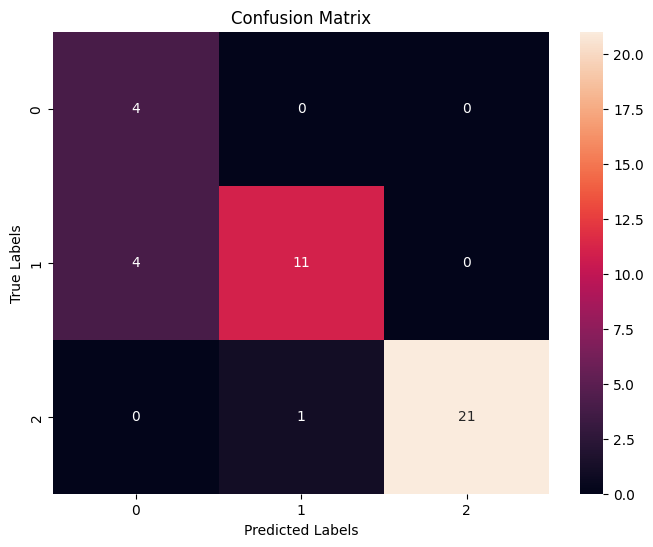

In [98]:
plt.figure(figsize=(8, 6)) #visualing the predicted vs actual values using confusion matrix and heatmap
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [101]:
param_grid=[{'C':[0.5,1,10,100],
            'gamma':['scale',1,0.1,.01,0.001,0.0001],
            'kernel':['rbf']}] # HyperParamaters

In [102]:
opt_param=GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy',verbose=0) # using Grid search for HyperParameter Tuning

In [104]:
opt_param.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.5, 1, 10, 100],
                          'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
                          'kernel': ['rbf']}],
             scoring='accuracy')

In [106]:
print(opt_param.best_score_)

0.9673333333333334


In [107]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [108]:
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=2),
             param_grid=[{'C': [0.5, 1, 10, 100],
                          'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
                          'kernel': ['rbf']}])

In [109]:
# Best parameters from GridSearch
best_params = grid_search.best_params_
print(f'Best Parameters: {best_params}')

Best Parameters: {'C': 0.5, 'gamma': 1, 'kernel': 'rbf'}


In [112]:
# Predicting with the best model
best_model = grid_search.best_estimator_
y_pred1 = best_model.predict(X_test)

In [113]:
accuracy = accuracy_score(y_test, y_pred1)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.90


In [114]:
cm = confusion_matrix(y_test, y_pred1)
cm

array([[ 4,  0,  0],
       [ 4, 11,  0],
       [ 0,  0, 22]])

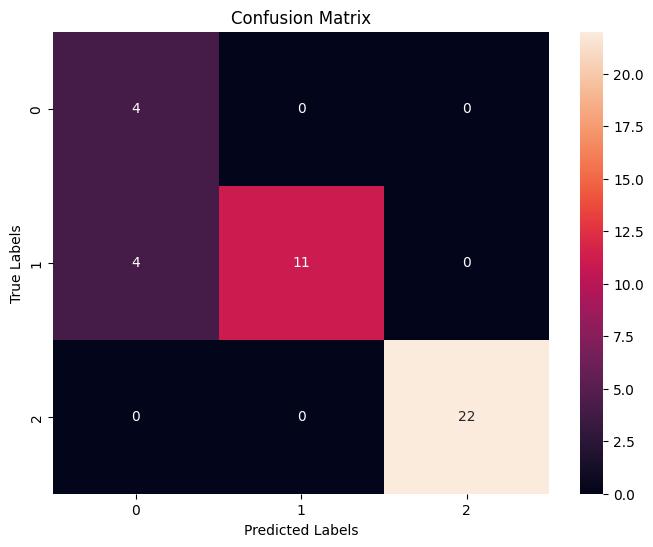

In [115]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

**OBSERVATION:**


*   Here we used SVC for classification of multiclass problem
*   Initially the model produced an accuracy of 87.80487804878049%
* Later we used the Grid search and Hyperparameter tuning for finding the best parameter and built the model using it
* Based on the best parameters, the newly built model produces an accuracy of 90%

